# From Ensembles to Deep Learning

Everything so far has been built on one model: a linear regression with a penalty on its
coefficients. That was a deliberate choice — every concept in this book (overfitting, leakage,
tuning, confounding, interpretation) is visible in a linear model, and visible more clearly for
the absence of machinery.

But the modern toolbox is much larger, and this chapter surveys it. The organizing question is not
*which algorithm is best* — there is no answer to that — but **what each family assumes**, and
therefore when each is likely to help.

## Inductive bias: what a model believes before it sees data

Every learning algorithm must choose among the many functions that fit the training data equally
well, and it does so according to built-in preferences. This is its **inductive bias**, and it is
not a defect to be minimized: without it, no generalization would be possible at all.

- A **linear model** believes the target is a weighted sum of the features. Ridge adds: prefer many
  small weights over a few large ones.
- A **decision tree** believes the target is constant within regions carved out by axis-aligned
  splits — it handles interactions, thresholds and non-linearity naturally, and smooth trends and
  extrapolation beyond the observed range badly.
- A **kernel method** such as an SVM believes similar inputs have similar outputs, where "similar"
  is defined by the kernel.
- A **neural network** believes the target is a composition of simple functions, and that useful
  representations can be built up in layers.

Choosing a model family is choosing a bias. The right one for your problem is an empirical
question, and — as chapters 4 and 5 insist — answering it by looking at your test set is cheating.

```{seealso}
{cite:t}`breiman2001two` is the essay that named this split in statistics: one culture assumes a
stochastic data model and interprets its parameters, the other treats the mechanism as unknown and
judges by predictive accuracy. Two decades on, it reads as a preview of everything in this book.
```

## Ensembles: many models are better than one

The single most reliable idea in applied machine learning is to combine models. Two mechanisms
dominate.

### Bagging and random forests

A deep decision tree has very high variance: change a few participants and you get a different
tree. **Bagging** (bootstrap aggregating) exploits this. Fit many trees to bootstrap resamples of
the data and average their predictions; the individual errors are partly independent, so averaging
cancels them. The bias stays roughly where it was, the variance falls.

**Random forests** {cite:p}`breiman2001random` add a second source of diversity: at each split,
only a random subset of the features is considered. This stops every tree from seizing on the same
dominant feature and makes the trees less correlated with one another — which is precisely what
makes averaging work. With strongly correlated features, as in our data, this matters a great deal.

### Boosting

Boosting builds models *sequentially*, each one fitted to the errors the previous ones left behind.
Where bagging averages independent high-variance models to reduce variance, boosting adds many
weak, high-bias models to reduce bias. Modern gradient boosting implementations (XGBoost, LightGBM,
CatBoost, and scikit-learn's `HistGradientBoosting`) are, by a wide margin, the most successful
family on tabular data.

The price is that boosting *can* overfit if allowed to run too long — the number of iterations is a
complexity dial exactly like the $\alpha$ of chapter 4, and it needs tuning exactly the same way.

### Stacking

A third approach: train several different models, then train a final model to combine their
predictions. Powerful, and an excellent way to leak if the combiner is fitted on predictions the
base models made on their own training data. It must be cross-validated throughout.

## Neural networks and deep learning

A neural network stacks layers of weighted sums and simple non-linearities. With enough units it
can approximate essentially any function — a fact that says less than it appears to, since the
question is never what a model *can* represent but what it will *learn* from limited data.

What makes deep learning transformative is not flexibility but **representation learning**. For
images, audio and text, hand-designed features were always the bottleneck, and a deep network
learns its own — which is why the field was overturned there and not, notably, on tabular data of
the size biomedical studies produce.

## So, do they help here?

Let us find out properly, on our dataset, with each model family tuned by nested cross-validation
so that nobody gets an unfair advantage.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict, KFold, GridSearchCV
from sklearn.metrics import mean_absolute_error

DATA_URL = "https://raw.githubusercontent.com/pni-lab/predmod_lecture/master/ex_data/IXI/ixi.csv"

ixi = pd.read_csv(DATA_URL).sample(frac=1, random_state=42).reset_index(drop=True)
TARGET = 'Age'
FEATURES = [c for c in ixi.columns if c.endswith('_volume')]
X = ixi[FEATURES].astype(float)
y = ixi[TARGET]

candidates = {
    'ridge': (Pipeline([('standardize', StandardScaler()), ('model', Ridge())]),
              {'model__alpha': [1, 10, 100, 1000, 10000]}),
    'elastic net': (Pipeline([('standardize', StandardScaler()),
                              ('model', ElasticNet(max_iter=20000))]),
                    {'model__alpha': [0.01, 0.1, 1], 'model__l1_ratio': [0.5, 0.9]}),
    'SVM (rbf kernel)': (Pipeline([('standardize', StandardScaler()), ('model', SVR())]),
                         {'model__C': [1, 10, 100]}),
    'random forest': (RandomForestRegressor(random_state=42, n_jobs=-1),
                      {'n_estimators': [300], 'max_features': [0.2, 0.5]}),
    'gradient boosting': (HistGradientBoostingRegressor(random_state=42),
                          {'max_depth': [2, 3], 'learning_rate': [0.05, 0.1], 'max_iter': [300]}),
    'neural network': (Pipeline([('standardize', StandardScaler()),
                                 ('model', MLPRegressor(random_state=42, max_iter=20000,
                                                       early_stopping=True, n_iter_no_change=20))]),
                       {'model__hidden_layer_sizes': [(32,), (64, 32)], 'model__alpha': [0.1, 1.0]}),
}

results = [{'model': 'baseline (mean age)',
            'MAE (years)': mean_absolute_error(y, np.full(len(y), y.mean())),
            'correlation r': np.nan}]   # a constant prediction has no correlation

for name, (estimator, grid) in candidates.items():
    tuned = GridSearchCV(estimator, grid, cv=KFold(5),
                         scoring='neg_mean_absolute_error', n_jobs=-1)
    predicted = cross_val_predict(tuned, X=X, y=y, cv=KFold(5))
    results.append({'model': name,
                    'MAE (years)': mean_absolute_error(y, predicted),
                    'correlation r': np.corrcoef(y, predicted)[0, 1]})

results = pd.DataFrame(results)
results.round(2)

,model,MAE (years),correlation r
0,baseline (mean age),14.93,NaN
1,ridge,9.84,0.70
2,elastic net,9.86,0.70
3,SVM (rbf kernel),9.11,0.71
4,random forest,9.11,0.72
5,gradient boosting,9.16,0.70
6,neural network,10.59,0.64


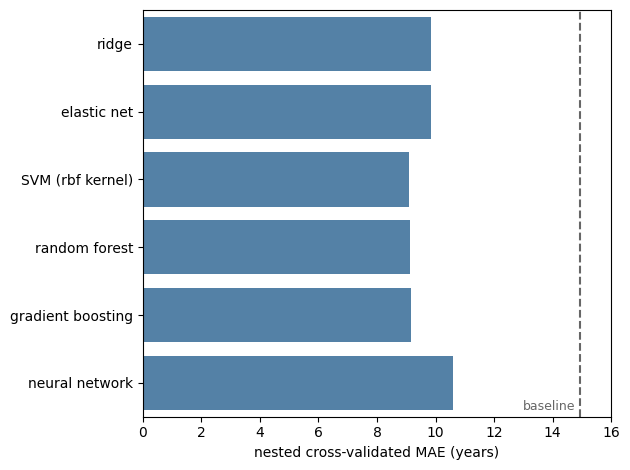

In [2]:
plot_data = results[results['model'] != 'baseline (mean age)']
ax = sns.barplot(data=plot_data, y='model', x='MAE (years)', color='steelblue')
ax.axvline(results.loc[0, 'MAE (years)'], ls='--', color='0.4')
ax.text(results.loc[0, 'MAE (years)'] - 0.15, 5.4, 'baseline', color='0.4', ha='right', fontsize=9)
ax.set_xlim(0, 16)
plt.xlabel('nested cross-validated MAE (years)')
plt.ylabel('')
plt.tight_layout()
plt.show()

Three things are worth taking from that table, and none of them is "use gradient boosting".

**The non-linear models do win — by a little.** The best of them beats the best linear model by
roughly seven-tenths of a year, about 7%. That is a real improvement and, in a competition, a
decisive one. It is also much smaller than most people expect, and far smaller than the gap between
*any* of these models and the baseline.

**The neural network is the worst model here.** Not because neural networks are bad, but because
638 participants and 68 pre-extracted features is exactly the regime where they have no advantage:
there are no raw representations left to learn — a FreeSurfer pipeline already did that work — and
there is nowhere near enough data to fit a flexible function well. Deep learning transformed the
analysis of *images*; this table is not an image, it is a spreadsheet.

**The spread between the best and worst model is smaller than the cost of getting chapters 3 to 5
wrong.** Our best model manages 9.1 years; the unregularized 68-feature model of
[chapter 3](../3_cross_validation/train_test.ipynb) managed 30. Algorithm choice is a
fine-tuning decision. Complexity control, honest validation and a sensible target are the decisions
that matter, and they come first.

## Complexity needs data

One more experiment, which explains most of the above. Let's run the comparison at several sample
sizes.

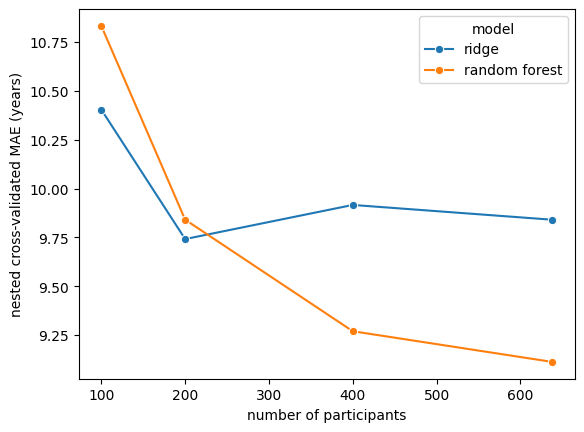

model,random forest,ridge
n,,
100,10.83,10.40
200,9.84,9.74
400,9.27,9.92
638,9.11,9.84


In [3]:
subsample_results = []
for n in [100, 200, 400, len(ixi)]:
    subset = ixi.iloc[:n]
    X_n, y_n = subset[FEATURES].astype(float), subset[TARGET]
    for name in ['ridge', 'random forest']:
        estimator, grid = candidates[name]
        tuned = GridSearchCV(estimator, grid, cv=KFold(5),
                             scoring='neg_mean_absolute_error', n_jobs=-1)
        predicted = cross_val_predict(tuned, X=X_n, y=y_n, cv=KFold(5))
        subsample_results.append({'n': n, 'model': name,
                                  'MAE (years)': mean_absolute_error(y_n, predicted)})

subsample_results = pd.DataFrame(subsample_results)

sns.lineplot(data=subsample_results, x='n', y='MAE (years)', hue='model', marker='o')
plt.xlabel('number of participants')
plt.ylabel('nested cross-validated MAE (years)')
plt.show()

subsample_results.pivot(index='n', columns='model', values='MAE (years)').round(2)

This is the practical rule behind all of it: **the more flexible the model, the more data it needs
before its flexibility pays.** At small sample sizes the simple model is competitive or better; the
flexible model's advantage grows as the sample does.

Which leads to the least glamorous and most reliable advice in machine learning: if your model is
not good enough, the first question is not *which algorithm should I try next* but *can I get more
data* — and the second is *is my target measured well enough for better prediction to be possible
at all*.

```{note}
**The no free lunch theorem** makes this formal: averaged over all possible problems, no learning
algorithm outperforms any other. Real problems are not drawn uniformly from all possible problems,
so in practice some algorithms are reliably useful — but there is no universally best one, and any
claim that a method is best must be relative to a class of problems. The empirical picture on
tabular data has been stable for years: gradient-boosted trees are the thing to beat.
```

## A short field guide

| if you have… | start with |
|---|---|
| tabular data, n in the hundreds | regularized linear model; try gradient boosting |
| tabular data, n in the thousands+ | gradient boosting, then a linear model as the honest baseline |
| images, audio, text, raw signals | a pretrained deep network, fine-tuned |
| very few participants, many features | strong regularization, dimensionality reduction, fewer choices |
| a need to explain every prediction | a linear model or a small tree, and measure what the simplicity costs |

In every row, the model is the easy part. What determines whether the result is worth anything is
what [chapter 6](../6_validity/index.md) covered: does it generalize, does it measure what you
claim, and who does it fail.

:::{admonition} Exercise 8.1
:class: tip, dropdown
Add a stacking model (`sklearn.ensemble.StackingRegressor`) combining ridge, random forest and
gradient boosting. Does it beat its components? Make sure the comparison is nested.
:::

:::{admonition} Exercise 8.2
:class: tip, dropdown
The random forest is tuned over just two settings here. Widen the grid substantially and re-run.
How much does the nested estimate improve — and what does your answer imply about the value of
extensive hyperparameter search?

:::{admonition} Solution
:class: note, dropdown
Very little, typically a tenth of a year or so, while the run time grows several-fold. Random
forests are famously insensitive to their hyperparameters, which is a large part of their appeal
as a default. Remember also from [chapter 5](../5_hyperparameter_optimization/nested_cross_validation.ipynb)
that a wider grid inflates the *optimistic* score more than the nested one — searching harder makes
the number you would have reported look better while the model gets no better at all.
:::
:::

:::{admonition} Exercise 8.3
:class: tip, dropdown
Re-run the whole comparison predicting a shuffled age variable (`y.sample(frac=1).values`). Every
model should land at the baseline. If any beats it, you have found a bug in your pipeline — and
this is a genuinely useful test to run on your own analyses.
:::